<a href="https://colab.research.google.com/github/NicoleRomanczuk/WineQuality_dataset/blob/main/Proyecto_Final_Data_Science_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final
- Estudiante: Nicole Romanczuk
- Curso: Data Science I
- Comisión: 77715

## Consigna Preentrega

1. Generar preguntas o hipótesis de interés sobre el data set elegido para el proyecto final.
2. Crear gráficos que usen al menos tres variables y hacer un diagnóstico de lo que los mismos nos están diciendo.
3. Vincular los gráficos y análisis numéricos hechos hasta el momento con las preguntas de interés.
4. Identificar valores perdidos.

## Consigna Proyecto Final

Crearás un notebook que complemente el trabajo realizado en los siguientes apartados:
1. Elegir un método de feature selection para reducir la dimensionalidad del dataset.
2. Elegir un algoritmo de regresión o clasificación para entrenar con los datos elegidos.
3. Cálculo de métricas básicas para validar el modelo.
4. Generar conclusiones con base en los resultados obtenidos.

### **1. Objetivos**

El **objetivo inicial** es identificar cuáles variables químicas y organolépticas están asociadas con la evaluación de calidad de los vinos.

El **objetivo final** es construir un modelo de Machine Learning para predecir el valor de calidad percibida del vino basándose en un conjunto de parámetros físicos y químicos.

### **2. Hipótesis planteadas**
1. El contenido de alcohol es un predictor de la calidad percibida.
2. Mayor aroma se asocia con mayor calidad.
3. La relación entre el contenido de alcohol y la calidad varía según el tipo de uva.
4. Los vinos tintos tienen mayor acidez volátil que los blancos.

### **3. Importar Librerías**

In [662]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configuraciones adicionales
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (8, 6)

### **4. Carga de Datos**

In [663]:
# Carga del dataset
df = pd.read_csv("https://raw.githubusercontent.com/NicoleRomanczuk/WineQuality_dataset/refs/heads/main/WineQuality_fixed.csv")


In [664]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32485 entries, 0 to 32484
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            32485 non-null  int64  
 1   fixed acidity         32485 non-null  float64
 2   volatile acidity      32485 non-null  float64
 3   citric acid           32485 non-null  float64
 4   residual sugar        32485 non-null  float64
 5   chlorides             32485 non-null  float64
 6   free sulfur dioxide   32485 non-null  float64
 7   total sulfur dioxide  32485 non-null  float64
 8   density               32485 non-null  float64
 9   pH                    32485 non-null  float64
 10  sulphates             32485 non-null  float64
 11  alcohol               32485 non-null  float64
 12  quality               32485 non-null  int64  
 13  Type                  32485 non-null  object 
 14  aroma                 32485 non-null  int64  
 15  tipo_uva           

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type,aroma,tipo_uva
0,2732,7.4,0.170,0.29,1.4,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,White Wine,7,Tempranillo
1,2607,5.3,0.310,0.38,10.5,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,White Wine,4,Merlot
2,1653,4.7,0.145,0.29,1.0,0.042,35.0,90.0,0.99080,3.76,0.49,11.3,6,White Wine,8,Tempranillo
3,3264,6.9,0.260,0.29,4.2,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,White Wine,5,Syrah
4,4931,6.4,0.450,0.07,1.1,0.030,10.0,131.0,0.99050,2.97,0.28,10.8,5,White Wine,7,Syrah


El dataset utilizado cuenta con 16 columnas y 32.485 entradas.

Incluye información correspondiente a distintas propiedades de los vinos, clasificadas en tres grupos:

Propiedades químicas:
* Acidez fija [g/L]
* Acidez volátil [g/L]
* Ácido cítrico [g/L]
* Azúcar residual [g/L]
* Cloruros [g/L]
* Dióxido de azufre libre [mg/L]
* Dióxido de azufre total [mg/L]
* pH
* Sulfatos [g/L]
* Alcohol [%]

Propiedades físicas:
* Densidad [g/cm^3]
* Tipo de uva

Propiedades organolépticas:
* Aroma
* Calidad

Composición:
* Tipo de uva




In [665]:
df.describe()

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,aroma
count,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000,32485.000000
mean,3251.548376,7.214736,0.340122,0.318324,5.438696,0.056009,30.458258,115.656303,0.994719,3.219089,0.531500,10.480694,5.811698,5.506572
std,1873.780954,1.308216,0.164912,0.145152,4.799221,0.034503,17.608076,56.456074,0.003015,0.161441,0.148712,1.190661,0.872474,2.873015
min,0.000000,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,1.000000
25%,1627.000000,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992400,3.110000,0.430000,9.500000,5.000000,3.000000
50%,3249.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994900,3.210000,0.510000,10.300000,6.000000,6.000000
75%,4875.000000,7.700000,0.410000,0.390000,8.100000,0.065000,41.000000,156.000000,0.997000,3.320000,0.600000,11.300000,6.000000,8.000000
max,6496.000000,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,10.000000


La columna Unnamed:0 no va a formar parte del análisis, ya que al no tener identificación del tipo de dato, no puede utilizarse para sacar conclusiones.

In [666]:
df = df.drop("Unnamed: 0", axis=1)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type,aroma,tipo_uva
0,7.4,0.170,0.29,1.4,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,White Wine,7,Tempranillo
1,5.3,0.310,0.38,10.5,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,White Wine,4,Merlot
2,4.7,0.145,0.29,1.0,0.042,35.0,90.0,0.99080,3.76,0.49,11.3,6,White Wine,8,Tempranillo
3,6.9,0.260,0.29,4.2,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,White Wine,5,Syrah
4,6.4,0.450,0.07,1.1,0.030,10.0,131.0,0.99050,2.97,0.28,10.8,5,White Wine,7,Syrah


### **5. Análisis Exploratorio de Datos (EDA)**

##### **5.1. Revisar valores faltantes**

In [667]:
# Análisis de valores faltantes en la base de datos
print("Valores faltantes por columna:")
df.isnull().sum()

Valores faltantes por columna:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


No se encuentran valores faltantes.

#### **5.2. Análisis del comportamiento de las variables**

Se dispone de diversas propiedades fisicoquímicas representadas por variables numéricas que podrían influir en la calidad del vino.

Se va a distinguir entre las variables categóricas y las numéricas.

Además se realiza un análisis inicial mediante una matriz de correlación, que posteriormente se representa en un heatmap, con el objetivo de identificar posibles relaciones entre las variables.

In [668]:
categorical_features = ["Type","tipo_uva"]

In [669]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
numerical_features

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'aroma']

In [670]:
columnas_numéricas = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "pH", "sulphates","density","aroma","alcohol", "quality"]
matriz_correlación = df[columnas_numéricas].corr()

print("\nMatriz de Correlación:")
matriz_correlación


Matriz de Correlación:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,density,aroma,alcohol,quality
fixed acidity,1.000000,0.223601,0.321191,-0.112334,0.304027,-0.283432,-0.334558,-0.256057,0.304817,0.462611,0.003956,-0.095564,-0.071026
volatile acidity,0.223601,1.000000,-0.380971,-0.203371,0.385263,-0.363466,-0.427682,0.256463,0.228995,0.271765,0.004775,-0.035792,-0.264435
citric acid,0.321191,-0.380971,1.000000,0.147234,0.032028,0.138716,0.199683,-0.325739,0.054573,0.101562,-0.002037,-0.013323,0.081732
residual sugar,-0.112334,-0.203371,0.147234,1.000000,-0.132078,0.407749,0.495762,-0.263937,-0.188288,0.553922,0.002390,-0.356700,-0.028114
chlorides,0.304027,0.385263,0.032028,-0.132078,1.000000,-0.203822,-0.285743,0.049273,0.388940,0.366588,0.000389,-0.255247,-0.201491
free sulfur dioxide,-0.283432,-0.363466,0.138716,0.407749,-0.203822,1.000000,0.722375,-0.144078,-0.193920,0.022125,-0.005122,-0.173432,0.066980
total sulfur dioxide,-0.334558,-0.427682,0.199683,0.495762,-0.285743,0.722375,1.000000,-0.236919,-0.278009,0.026584,-0.002885,-0.261329,-0.034580
pH,-0.256057,0.256463,-0.325739,-0.263937,0.049273,-0.144078,-0.236919,1.000000,0.195759,0.007378,-0.007764,0.126799,0.027867
sulphates,0.304817,0.228995,0.054573,-0.188288,0.388940,-0.193920,-0.278009,0.195759,1.000000,0.260468,-0.004107,-0.000122,0.038585
density,0.462611,0.271765,0.101562,0.553922,0.366588,0.022125,0.026584,0.007378,0.260468,1.000000,0.002084,-0.677900,-0.292981



Heatmap de Correlaciones entre Variables Numéricas:


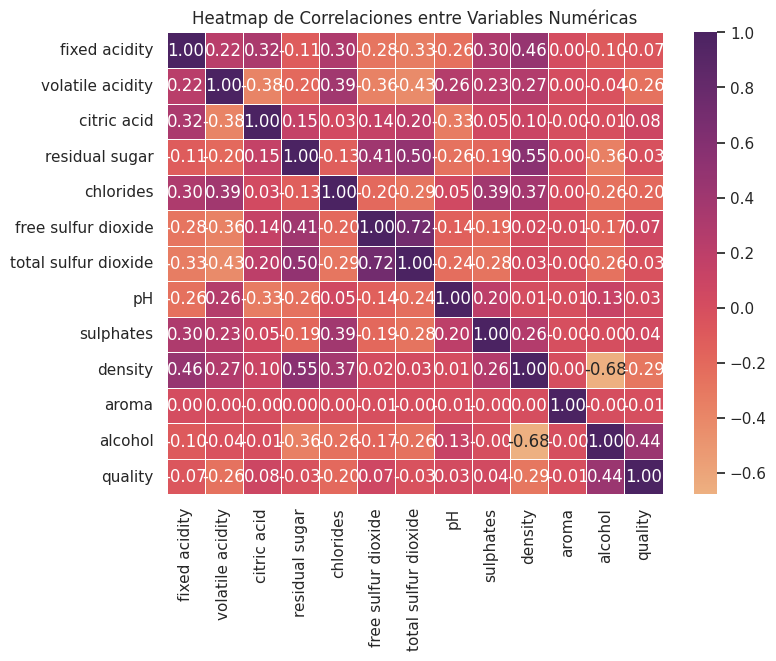

In [671]:
sns.heatmap(matriz_correlación, annot=True, cmap="flare", fmt=".2f", linewidths=.5)

plt.title('Heatmap de Correlaciones entre Variables Numéricas')
print("\nHeatmap de Correlaciones entre Variables Numéricas:")
plt.show()

In [672]:
matriz_correlación["quality"].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.438075
citric acid,0.081732
free sulfur dioxide,0.066980
sulphates,0.038585
pH,0.027867
aroma,-0.006574
residual sugar,-0.028114
total sulfur dioxide,-0.034580
fixed acidity,-0.071026


Se observa que la variable que más relacionada está con la calidad es el **contenido de alcohol**, lo cual coincide con lo planteado en la Hipótesis 1.

Además, se puede concluir que muchas propiedades fisicoquímicas presentan una influencia poco significativa sobre la calidad, ya que muestran valores en la matriz de correlación muy cercanos a 0. Entre ellas se destacan la **acidez fija**, el **ácido cítrico**, el **azúcar residual**, el **dióxido de azufre libre**, el **dióxido de azufre total**, el **pH** y los **sulfatos**. El aroma tampoco tiene influencia sobre la calidad percibida.

En cambio, variables como la **acidez volátil**, los **cloruros** y la **densidad** presentan una correlación negativa con la calidad percibida.

A continuación se realiza un análisis de la distribución de calidades percibidas de las distintas muestras de vinos:


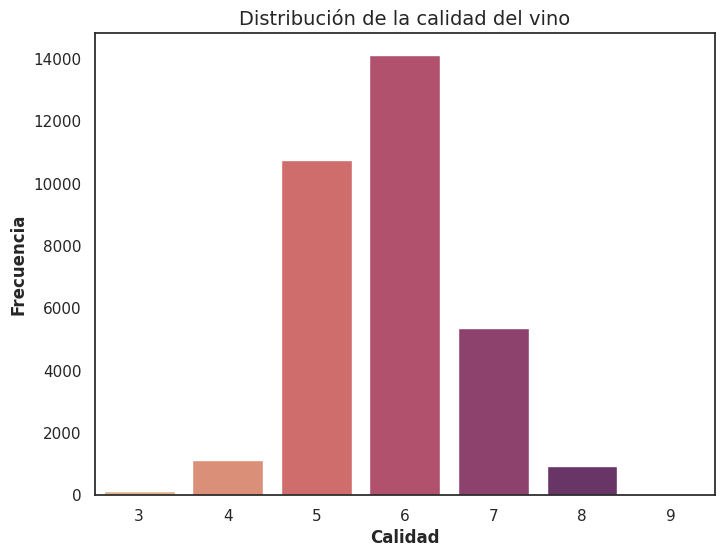

In [673]:
sns.countplot(x="quality", hue="quality", data=df, palette="flare", legend=False)
plt.title("Distribución de la calidad del vino", fontsize=14)
plt.xlabel("Calidad", fontsize=12, fontweight="bold")
plt.ylabel("Frecuencia", fontsize=12, fontweight="bold")
print("A continuación se realiza un análisis de la distribución de calidades percibidas de las distintas muestras de vinos:")
plt.show()

In [674]:
print("Se puede observar que el valor que más se repite en calidad percibida es")
moda = df["quality"].mode()[0]
print(moda)

Se puede observar que el valor que más se repite en calidad percibida es
6


Boxplot para la relación entre el contenido de alcohol y la calidad:


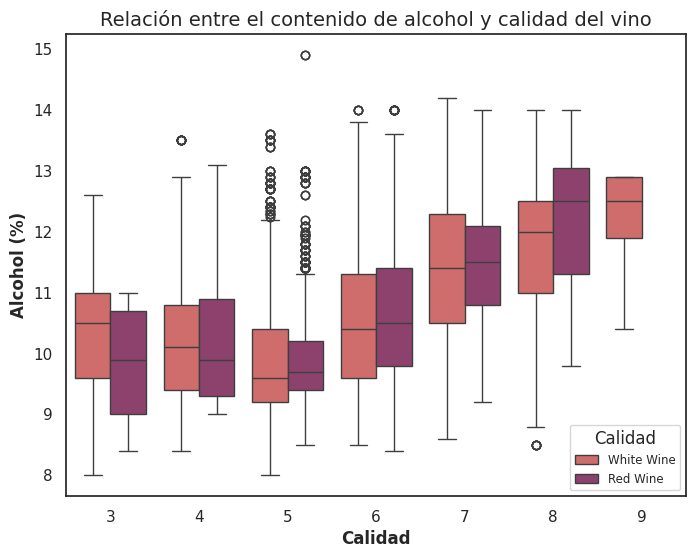

In [675]:
plt.figure(figsize=(8,6))
sns.boxplot(x="quality", hue="Type", y="alcohol", data=df, palette="flare")
plt.title("Relación entre el contenido de alcohol y calidad del vino",  fontsize=14)
plt.xlabel("Calidad", fontsize=12, fontweight="bold")
plt.ylabel("Alcohol (%)",  fontsize=12, fontweight="bold")
plt.legend(loc="lower right", fontsize=8.5, title="Calidad")
print("Boxplot para la relación entre el contenido de alcohol y la calidad:")
plt.show()

En la Figura se observa la relación entre el contenido de alcohol y la calidad del vino.

Se aprecia una tendencia creciente del contenido de alcohol a medida que aumenta la calidad, lo que indica que los vinos mejor evaluados presentan, en general, **mayores concentraciones de alcohol**.

Además, se destaca que las categorías de calidad más alta exhiben una mayor dispersión en los valores de alcohol, mientras que en los vinos de baja calidad el contenido alcohólico es más uniforme.

Para ampliar el análisis, también se distingue si el vino es blanco o tinto. Se observan diferencias en la dispersión de los datos, pero se mantiene la tendencia creciente. Como caso particular, los vinos clasificados con mayor calidad son únicamente blancos.

Esta tendencia **confirma lo planteado en la Hipótesis 1**, donde se propone que el contenido de alcohol actúa como un predictor de la calidad percibida del vino.

Boxplot para la relación entre el aroma y la calidad:


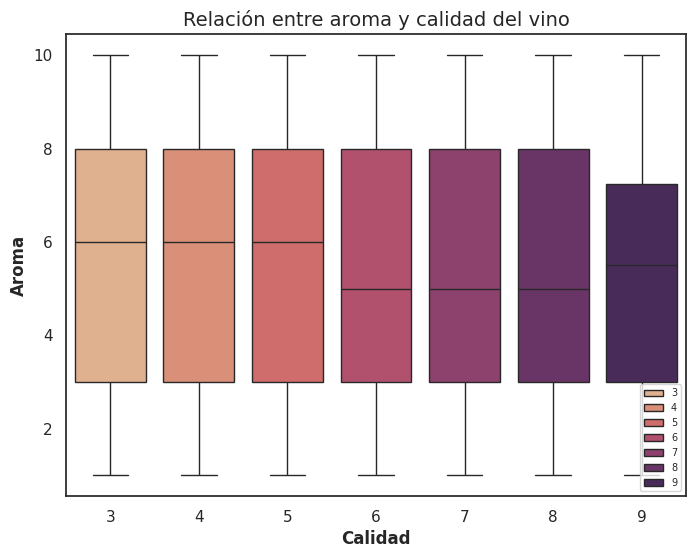

In [676]:
sns.boxplot(x="quality", hue="quality", y="aroma", data=df, palette="flare")
plt.title("Relación entre aroma y calidad del vino", fontsize=14)
plt.xlabel("Calidad", fontsize=12, fontweight="bold")
plt.ylabel("Aroma",fontsize=12, fontweight="bold")
plt.legend(loc="lower right", fontsize=7)
print("Boxplot para la relación entre el aroma y la calidad:")
plt.show()

En la Figura se presenta la relación entre el aroma y la calidad del vino. A diferencia del contenido de alcohol, **no se observa una tendencia clara entre ambas variables**, ya que las medianas de aroma se mantienen prácticamente constantes a lo largo de las diferentes categorías de calidad.
Además, se aprecia una alta dispersión de los valores de aroma en todos los niveles de calidad, lo que indica una variabilidad considerable dentro de cada grupo.

En consecuencia, puede inferirse que el aroma no muestra una relación significativa con la calidad percibida del vino, por lo que **no se confirma la Hipótesis 2**, que planteaba una asociación positiva entre estas variables.

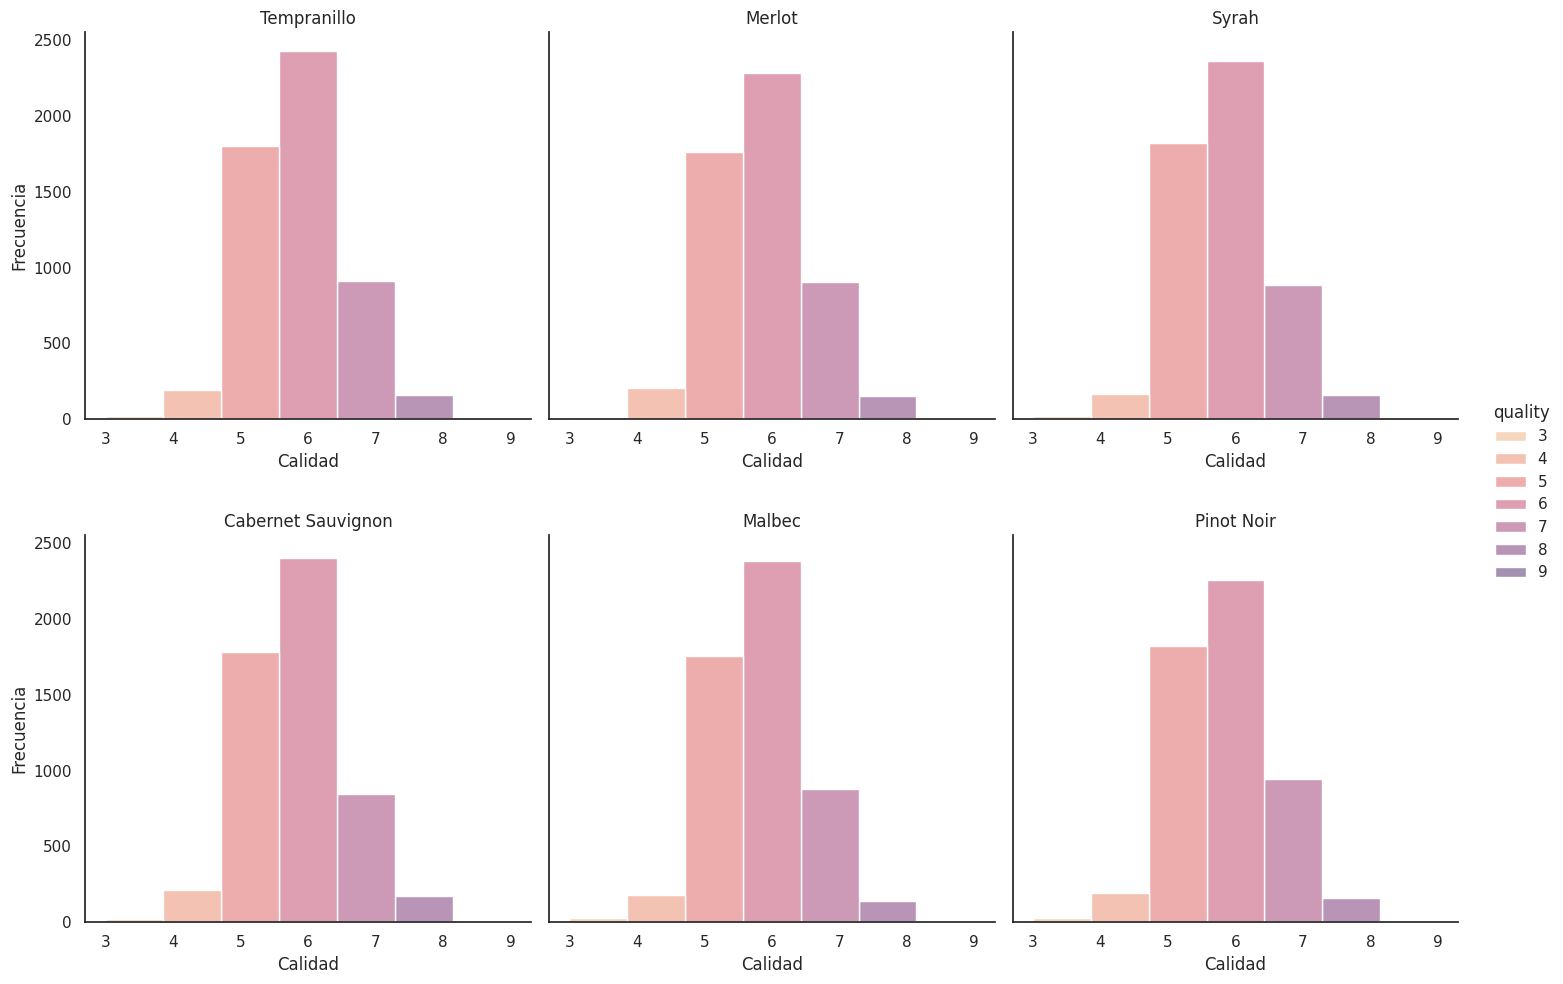

In [645]:
grid = sns.displot(data=df, x="quality", col="tipo_uva",
                   hue="quality", palette="flare",
                   bins=7, col_wrap=3)
for ax in grid.axes.flatten():
    ax.set_xlabel("Calidad") # Nombre del eje x
    ax.tick_params(axis='x', labelbottom=True) # Para que siga mostrando los valores en la primera fila
    ax.xaxis.label.set_visible(True) # Muestra el nombre del eje x en la primera fila

grid.set_ylabels("Frecuencia")
grid.set_titles(col_template="{col_name}") # Para que los gráficos tengan el título correspondiente

grid.fig.subplots_adjust(hspace=0.3) # Ajusto la distancia entre las dos filas

plt.show()

A partir de este análisis se puede concluir que el tipo de uva utilizado *no influye en la calidad percibida*, ya que la distribución de la calidad es prácticamente igual para los 6 tipos de uva analizados.

En consecuencia, es poco probable que la relación entre el contenido de alcohol y la calidad varíe según el tipo de uva, por lo que **la Hipótesis 3 no se ve confirmada** a partir de estos resultados.

Boxplot para la relación entre la acidez volátil y el tipo de vino:


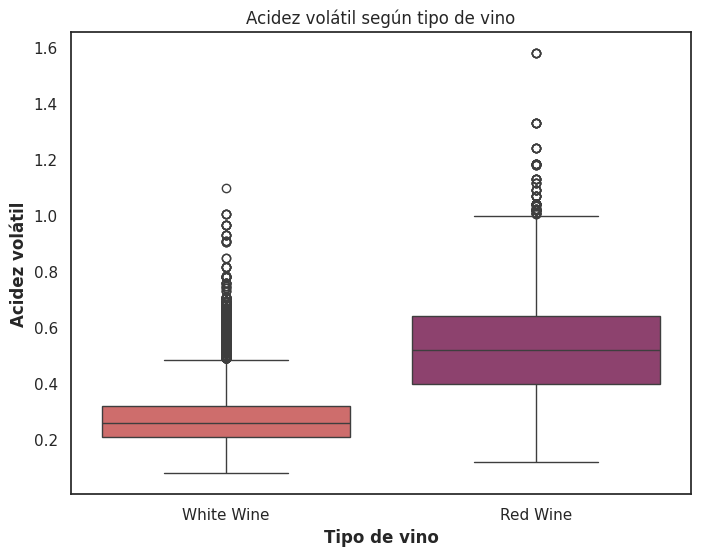

In [646]:
sns.boxplot(data=df, x="Type", y="volatile acidity",
            hue="Type", palette="flare")
plt.title("Acidez volátil según tipo de vino")
plt.xlabel("Tipo de vino", fontsize=12, fontweight="bold")
plt.ylabel("Acidez volátil",fontsize=12, fontweight="bold")
print("Boxplot para la relación entre la acidez volátil y el tipo de vino:")
plt.show()

En la Figura se muestra la comparación de la acidez volátil según el tipo de vino.

Se observa que los vinos tintos presentan valores de acidez volátil considerablemente más altos que los vinos blancos, tanto en la mediana como en la dispersión general de los datos. En cambio, los vinos blancos exhiben valores más bajos y concentrados, con una menor variabilidad. Además, ambos tipos de vino presentan valores atípicos, aunque son más numerosos en el vino blanco.

En conjunto, estos resultados indican que la acidez volátil es una característica distintiva entre vinos tintos y blancos, siendo típicamente más elevada en los tintos, lo cual puede influir en su perfil sensorial y en la percepción de calidad.

En conclusión, **se confirma la Hipótesis 4**.

### **6. Feature Engineering**

#### **6.1. Discretización**

La calidad percibida del vino se expresa en números enteros con valores posibles entre 0 y 10.

Este valor de calidad puede categorizarse en grupos para asignarle una segmentación.

En la sección anterior se realizó un countplot analizando la frecuencia de cada una de las calidad percibidas.

Se va a analizar en que valores realizar los cortes de las categorías a asignar para tener una segmentación de los datos balanceada y evitar modelos que predigan siempre la misma categoría.

In [647]:
#Análisis del conteo en cada característica para segmentar mejor:
df["quality"].value_counts().sort_index()

,count
quality,
3,133
4,1144
5,10755
6,14117
7,5371
8,941
9,24


Como ya se había analizado anteriormente, la mayoría de las calificaciones se encuentran entre 5 y 6.

Por lo tanto, se va a separar la calidad percibida en las siguientes categorías:
- 0 a 5 : Baja
- 6 : Media
- 7 a 10 : Alta

In [648]:
# Creación de bins para la columna "quality"
bins = [0,5,6,df["quality"].max()] #Cortes en 0,5,6 y 10.
labels = ["Baja","Media","Alta"]

# Creación de una nueva columna con esta nueva categoría
df["quality_group"] = pd.cut(df["quality"], bins=bins, labels=labels, right=True)
#True para definir el intervalo que quiero

display(df[["quality","quality_group"]].head(8)) #Head 8 para ver más clasificaciones
print("\nConteo de vinos en cada grupo de clasificación:")
df["quality_group"].value_counts()

,quality,quality_group
0,6,Media
1,6,Media
2,6,Media
3,6,Media
4,5,Baja
5,6,Media
6,6,Media
7,7,Alta



Conteo de vinos en cada grupo de clasificación:


,count
quality_group,
Media,14117
Baja,12032
Alta,6336


Utilizando esta clasificación se observa que las categorías están bien representadas.

Para codificar las variables nominales se utiliza One-Hot Encoding y Label Enconder

### **7. División de Datos**

In [649]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
#Elimino las columnas de quality y quality group porque son mi objetivo.
numerical_features_for_scaling = [col for col in numerical_features if col not in ["quality","quality_group"]]
numerical_features_for_scaling

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'aroma']

In [650]:
df.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'Type',
 'aroma',
 'tipo_uva',
 'quality_group']

In [651]:
categorical_features= [col for col in df.columns if col.startswith("Type_")]
categorical_features

[]

In [652]:
features = numerical_features_for_scaling + categorical_features
target = "quality_group"

In [653]:
# Defino las características (X) y la variable objetivo (y)
X = df[features]
y = df[target]

In [654]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [655]:
#One-Hot Enconding para el tipo de vino, blanco o tinto
df = pd.get_dummies(df, columns=["Type"], drop_first=True)
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,aroma,tipo_uva,quality_group,Type_White Wine
0,7.4,0.170,0.29,1.4,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,7,Tempranillo,Media,True
1,5.3,0.310,0.38,10.5,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,4,Merlot,Media,True
2,4.7,0.145,0.29,1.0,0.042,35.0,90.0,0.99080,3.76,0.49,11.3,6,8,Tempranillo,Media,True
3,6.9,0.260,0.29,4.2,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,5,Syrah,Media,True
4,6.4,0.450,0.07,1.1,0.030,10.0,131.0,0.99050,2.97,0.28,10.8,5,7,Syrah,Baja,True


In [656]:
#Encontré mapping en lugar deLabelEncoder para la columna de la calidad categorizada
#para poner el orden que quiero
mapping = {"Baja": 0, "Media": 1, "Alta": 2}
df["quality_group"] = df["quality_group"].map(mapping)
display(df.head())


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,aroma,tipo_uva,quality_group,Type_White Wine
0,7.4,0.170,0.29,1.4,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,7,Tempranillo,1,True
1,5.3,0.310,0.38,10.5,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,4,Merlot,1,True
2,4.7,0.145,0.29,1.0,0.042,35.0,90.0,0.99080,3.76,0.49,11.3,6,8,Tempranillo,1,True
3,6.9,0.260,0.29,4.2,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,5,Syrah,1,True
4,6.4,0.450,0.07,1.1,0.030,10.0,131.0,0.99050,2.97,0.28,10.8,5,7,Syrah,0,True


### **7. Feature Scaling**



In [657]:
 #Escalo los datos numéricos
scaler = StandardScaler()

X_train[numerical_features_for_scaling] = scaler.fit_transform(X_train[numerical_features_for_scaling])

X_test[numerical_features_for_scaling] = scaler.transform(X_test[numerical_features_for_scaling])


### **8. Entrenamiento del Modelo (Random Forest)**

In [658]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### **9. Evaluación del Modelo**

#### 9.1. Accuracy

In [659]:
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.9946


#### 9.2. Matriz de Confusión

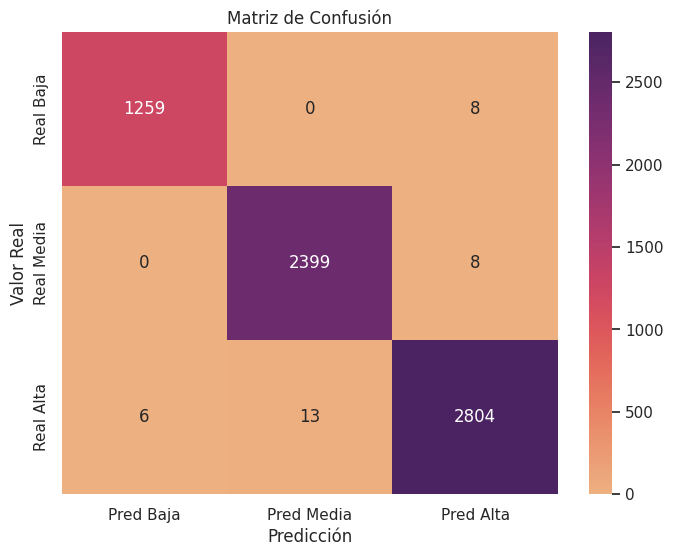

In [660]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='flare', xticklabels=["Pred Baja","Pred Media","Pred Alta"], yticklabels=["Real Baja", "Real Media","Real Alta"])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()


Los valores altos sobre la diagonal principal indican que el modelo acierta en la gran mayoría de los casos, 1259 vinos realmente "Baja" fueron clasificados correctamente, 2399 "Media" y 2804 "Alta".

Los errores son muy pocos. La clase "Baja" presenta únicamente 8 vinos confundidos con "Alta" y ninguno con "Media". En "Media", solo 8 casos fueron clasificados como "Alta" y ninguno como "Baja", lo cual sugiere que el modelo prácticamente no comete errores graves. La clase "Alta" muestra 6 vinos etiquetados como "Baja" y 13 como "Media", pero sigue siendo un nivel de error muy reducido considerando el tamaño del conjunto.

#### 9.3. Reporte de Clasificación

In [661]:
target_names = ["Baja", "Media", "Alta"]
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

        Baja       1.00      0.99      0.99      1267
       Media       0.99      1.00      1.00      2407
        Alta       0.99      0.99      0.99      2823

    accuracy                           0.99      6497
   macro avg       0.99      0.99      0.99      6497
weighted avg       0.99      0.99      0.99      6497



### **10. Conclusiones**

La clasificación en tres categorías (Baja, Media, Alta) quedó correctamente definida y balanceada. Se verificó el orden de etiquetas usando un mapeo explícito, evitando inconsistencias en el label encoding.

El modelo Random Forest obtuvo un rendimiento muy alto, con accuracy ≈ 0.99 y valores de precisión, recall y f1-score entre 0.99 y 1.00. Esto indica que las características disponibles permiten separar muy bien las clases.

No se observó desbalance crítico entre clases. La clase “Media” presentó el mejor recall, lo que sugiere que el modelo la identifica con total fiabilidad.


Los resultados no parecen inflados artificialmente, sino consecuencia de un problema altamente separable.

El modelo es adecuado para predecir el grupo de calidad y puede utilizarse como herramienta de clasificación para futuros datos, con buen nivel de confianza.